# Toy model: an unknown number of spins, with parallel tempering

`toy_rjmcmc_ten_sites` ended on a problem. Two runs on the same data, with
different random seeds, settled on different answers: one on the three true
sites, the other with a fourth spin stuck on site 9 and site 3 pulled
10 kHz off its true coupling to compensate. Each run reported its own
answer for every kept step, and neither ever visited the other's.

This notebook adds **parallel tempering** as a fourth block of the schedule.
Several copies of the configuration, the *rungs* of a ladder, are run side
by side. The cold rung samples the real posterior. Each hotter rung samples
a flattened version of it, in which a poor fit costs less, so a hot rung can
drop a spin or drag a coupling across a region the cold rung would never
enter. Every sweep, two rungs are picked and may exchange configurations.
That is how a configuration found by a hot rung reaches the cold one.

| block | move | what it changes |
|---|---|---|
| **RJMCMC** | birth or death of one spin | the number of spins |
| **site walk** | one spin hops to an unoccupied site | which sites are occupied |
| **offset walk** | one component of one spin's offset takes a step | the couplings |
| **tempering** | every rung does a little of all three, then two rungs may swap | everything, by exchange |

The lattice, the three true spins, the site-sized ±10% rectangles and the
per-site memory are those of the previous notebook. Only the cold rung is
recorded.

As before, this is the package's site memory, switched on with
`site_memory=True`.

In [1]:
import collections
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, Rectangle

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RJMCMC,
    RWMH,
    AnalyticCCE1,
    BirthDeathKernel,
    DiscreteLatticeWalk,
    Envelope,
    Experiment,
    ExperimentSet,
    GaussianL2,
    HybridDriver,
    NeighborIndex,
    ParallelTempering,
    ParameterBlock,
    Schedule,
    SiteScaledOffset,
    SiteTable,
    State,
    Step,
    Target,
    Trace,
    gyromagnetic_ratio,
    simulate_coherence,
    simulate_dataset,
)

# One colour per algorithm, used for the stripes in section 4 and nowhere
# else.  Samples are a single colour, because spins are born and die and have
# no identity to follow; sites are labelled by number.
ALGORITHM_COLOURS = {"RJMCMC": "#2a78d6", "site walk": "#eb6834",
                     "offset walk": "#1baf7a", "tempering": "#eda100"}
C_SAMPLE, C_RECOVERED = "#2a78d6", "#4a3aa7"
C_INK, C_MUTED, C_GRID, C_AXIS = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
C_SOFT = "#f0efec"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_AXIS, "axes.labelcolor": "#52514e",
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "grid.color": C_GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "figure.dpi": 110,
})

## 1. The lattice and the truth

The same ten sites as the previous notebook, with the same three true spins.

In [2]:
FRACTION = 0.10                        # each component may move ±10%

CENTRES = np.array([
    (100.0, 100.0),    # 0
    (10.0, 10.0),      # 1
    (100.0, 50.0),     # 2
    (60.0, 80.0),      # 3
    (150.0, 60.0),     # 4
    (40.0, 30.0),      # 5
    (75.0, 120.0),     # 6
    (130.0, 110.0),    # 7
    (25.0, 60.0),      # 8
    (55.0, 45.0),      # 9
])
N_SITES = len(CENTRES)
HALF = FRACTION * np.abs(CENTRES)      # (n_sites, 2) half-widths, kHz

# The spins the data are simulated from: site -> offset from its table value.
TRUE = {2: (5.0, 2.0), 3: (-4.0, 5.0), 7: (8.0, -6.0)}
TRUE_SITES = tuple(sorted(TRUE))
START_SITES = (0,)                     # one spin, on a site that is not true
K_MAX = 6

# Real-space positions only decide which sites are neighbours.  The ten sit on
# a ring and the walk radius reaches all of them.
_angle = np.linspace(0.0, 2.0 * np.pi, N_SITES, endpoint=False)
POSITIONS = np.column_stack([2.0 * np.cos(_angle), 2.0 * np.sin(_angle),
                             np.full(N_SITES, 2.0)])
HOP_RADIUS = 10.0

table = SiteTable(
    distance=np.linalg.norm(POSITIONS, axis=1), positions=POSITIONS,
    a_par=CENTRES[:, 0], a_perp=CENTRES[:, 1],
    isotope=np.array(["13C"] * N_SITES),
    gyro=np.full(N_SITES, gyromagnetic_ratio("13C")))

print(f"{'site':>4s} {'A_par':>7s} {'A_perp':>7s}   allowed range (kHz)")
for i in range(N_SITES):
    note = "   <- true spin, offset ({:+.0f}, {:+.0f})".format(*TRUE[i]) \
        if i in TRUE else ("   <- start" if i in START_SITES else "")
    print(f"{i:4d} {CENTRES[i, 0]:7.0f} {CENTRES[i, 1]:7.0f}   "
          f"±{HALF[i, 0]:4.1f} × ±{HALF[i, 1]:4.1f}{note}")

site   A_par  A_perp   allowed range (kHz)
   0     100     100   ±10.0 × ±10.0   <- start
   1      10      10   ± 1.0 × ± 1.0
   2     100      50   ±10.0 × ± 5.0   <- true spin, offset (+5, +2)
   3      60      80   ± 6.0 × ± 8.0   <- true spin, offset (-4, +5)
   4     150      60   ±15.0 × ± 6.0
   5      40      30   ± 4.0 × ± 3.0
   6      75     120   ± 7.5 × ±12.0
   7     130     110   ±13.0 × ±11.0   <- true spin, offset (+8, -6)
   8      25      60   ± 2.5 × ± 6.0
   9      55      45   ± 5.5 × ± 4.5


## 2. The sampler

CPMG-4 and no envelope, as in the earlier toy notebooks.

The three single-chain moves are those of the previous notebook, and the
ladder is the package's `ParallelTempering` wrapped around them.

**Each rung has its own memory.** A site's remembered offset is part of the
state, so each rung of the ladder carries its own copy, and a swap exchanges
two rungs' memories along with their spins. Nothing extra is needed for
that.

**`RecordingTempering`** is the only class local to this notebook. It
changes nothing about the sampling: it keeps a record of every rung's
misfit and of each swap, for the figures in sections 4 and 5.

Two properties of the package's tempering matter for reading the results:

- The inverse temperatures halve from rung to rung: 1, 1/2, 1/4, and so on.
  With eight rungs the hottest is at 1/128, where a misfit of 100 costs
  what a misfit of less than 1 costs the cold rung.
- The ladder lives for one tempering block. At the start of each block
  every rung is a copy of the cold one; at the end, the hot rungs are
  discarded.

In [3]:
DATA_NOISE, LIK_SIGMA = 0.002, 0.02
N_PULSES, B_Z = 4, 311.0
tau = np.linspace(3.2e-5, 8e-3, 250)   # ms
blank = ExperimentSet([Experiment(tau=tau, n_pulses=N_PULSES, b_z=B_Z)])


class NoEnvelope(Envelope):
    """No attenuation: the coherence is the spin modulation alone."""

    def __call__(self, tau, exp_id, lam, n_stretch):
        return np.ones_like(np.asarray(tau, dtype=float))


class RecordingTempering(ParallelTempering):
    """The package's parallel tempering, keeping a record for the figures."""

    def __init__(self, inner, n_replicas):
        super().__init__(inner, n_replicas=n_replicas)
        #: Per sweep: every rung's untempered log-likelihood, and whether a
        #: swap involving the cold rung was accepted.
        self.rung_log_like = []
        self.cold_swapped = []
        self.block_starts = []
        self.n_swaps = 0

    def attempt_swap(self, state, target, rng):
        out = super().attempt_swap(state, target, rng)
        a, b, accepted = self.last_swap
        self.rung_log_like.append(target.log_prob(out, beta=1.0))
        self.cold_swapped.append(accepted and 0 in (a, b))
        self.n_swaps += int(accepted)
        return out

    def run(self, state, target, rng, n_steps, trace=None, beta=1.0):
        self.block_starts.append(len(self.rung_log_like))
        return super().run(state, target, rng, n_steps, trace=trace, beta=beta)


#: The label each algorithm writes to the trace, and its name in the figures.
ALGORITHM_NAMES = {
    "rjmcmc:sites": "RJMCMC",
    "rwmh:sites": "site walk",
    "rwmh:offsets": "offset walk",
    "pt:sites+sites+offsets": "tempering",
}

model = AnalyticCCE1(NoEnvelope())


def make_state(sites, offsets=None):
    """Spins on ``sites``, each offset from its table value."""
    state = State.from_sites(
        tuple(int(s) for s in sites), n_sites=N_SITES, n_exp=1,
        # A State must carry a decay constant; NoEnvelope never reads it.
        lam=np.ones((1, 1)), n_stretch=np.ones((1, 1)),
        sigma=np.full((1, 1), LIK_SIGMA), k_max=K_MAX, site_memory=True)
    if offsets is not None:
        for slot, (d_par, d_perp) in enumerate(offsets):
            state.set_offset(0, slot, 0, d_par)
            state.set_offset(0, slot, 1, d_perp)
    return state


truth = make_state(TRUE_SITES, [TRUE[s] for s in TRUE_SITES])
data = simulate_dataset(truth, blank, table, model, sigma=DATA_NOISE,
                        rng=np.random.default_rng(3))
target = Target(data, model, GaussianL2(), table)

## 3. One run

A cycle is 100 steps: 10 of RJMCMC, 10 of the site walk, 40 of the offset
walk, and 40 tempering sweeps.

A tempering sweep is one recorded step but a great deal more work than the
others. In one sweep every one of the eight rungs does 1 RJMCMC step, 1 site
step and 4 offset steps, and then one swap is tried: 48 moves for one line
of the trace.

The recovered configuration is defined as in the previous notebook: the
most often visited set of sites after burn-in, with the couplings of the
highest-likelihood sample on that set.

In [4]:
N_STEPS, N_BURN = 12000, 3000
BLOCKS = {"RJMCMC": 10, "site walk": 10, "offset walk": 40, "tempering": 40}
N_RUNGS = 8
INNER = {"RJMCMC": 1, "site walk": 1, "offset walk": 4}
STEP_KHZ = 1.0


def run_walk(seed, tempering=True):
    moves = {
        "RJMCMC": RJMCMC(ParameterBlock("sites"), BirthDeathKernel(k_max=K_MAX)),
        "site walk": RWMH(
            ParameterBlock("sites"),
            DiscreteLatticeWalk(NeighborIndex(POSITIONS, HOP_RADIUS))),
        "offset walk": RWMH(ParameterBlock("offsets"), SiteScaledOffset(
            STEP_KHZ, table, fraction_par=FRACTION, fraction_perp=FRACTION,
            prior="flat")),
    }
    blocks = [Step(moves[name], BLOCKS[name]) for name in moves]
    ladder = None
    if tempering:
        ladder = RecordingTempering(
            Schedule([Step(moves[name], INNER[name]) for name in moves]),
            n_replicas=N_RUNGS)
        blocks.append(Step(ladder, BLOCKS["tempering"]))
    initial = make_state(START_SITES)
    trace = Trace(n_sites=N_SITES, k_max=K_MAX, n_exp=1)
    HybridDriver(Schedule(blocks)).run(
        initial, target, np.random.default_rng(seed), N_STEPS, trace=trace)

    # The trace records the state after each step; put the start at the front.
    # Arrays are (step, slot); an empty slot has site -1.
    k = np.concatenate([initial.k, trace.k])
    site = np.vstack([initial.site_idx[0], trace.site_idx])
    live = np.arange(K_MAX)[None, :] < k[:, None]
    site = np.where(live, site, -1)
    d_par = np.vstack([initial.dA_par[0], trace.dA_par])
    d_perp = np.vstack([initial.dA_perp[0], trace.dA_perp])
    safe = np.clip(site, 0, None)
    log_like = np.concatenate([target.log_prob(initial),
                               np.asarray(trace.log_prob)])
    occupancy = np.zeros((len(k), N_SITES), dtype=bool)
    for slot in range(K_MAX):
        rows = np.flatnonzero(live[:, slot])
        occupancy[rows, site[rows, slot]] = True

    # Step t is the move from row t-1 to row t.
    algorithm = np.array([ALGORITHM_NAMES[a] for a in trace.algorithm])
    changed = (occupancy[1:] != occupancy[:-1]).any(axis=1)
    dk = np.diff(k)
    sweep_steps = np.flatnonzero(algorithm == "tempering") + 1
    cold_swaps = (sweep_steps[np.array(ladder.cold_swapped, dtype=bool)]
                  if tempering else np.array([], dtype=int))

    configs = [tuple(np.flatnonzero(row)) for row in occupancy]
    counts = collections.Counter(configs[N_BURN:])
    modal = counts.most_common(1)[0][0]
    on_modal = np.array([c == modal for c in configs])
    on_modal[:N_BURN] = False
    best = int(np.flatnonzero(on_modal)[np.argmax(log_like[on_modal])])
    recovered = make_state(
        site[best, : k[best]],
        list(zip(d_par[best, : k[best]], d_perp[best, : k[best]], strict=True)))

    return {
        "seed": seed, "tempering": tempering, "k": k, "site": site,
        "live": live, "d_par": d_par, "d_perp": d_perp,
        "a_par": np.where(live, CENTRES[safe, 0] + d_par, np.nan),
        "a_perp": np.where(live, CENTRES[safe, 1] + d_perp, np.nan),
        "log_like": log_like, "occupancy": occupancy, "algorithm": algorithm,
        "births": np.flatnonzero(dk > 0) + 1,
        "deaths": np.flatnonzero(dk < 0) + 1,
        "hops": np.flatnonzero((dk == 0) & changed) + 1,
        "cold_swaps": cold_swaps, "sweep_steps": sweep_steps,
        "ladder": ladder,
        "config_counts": counts, "modal": modal, "best": best,
        "initial": initial, "recovered": recovered,
    }


def report(res):
    kept = N_STEPS + 1 - N_BURN
    print(f"changes to the recorded chain: {res['births'].size} births, "
          f"{res['deaths'].size} deaths, {res['hops'].size} site hops")
    if res["tempering"]:
        ladder = res["ladder"]
        sweeps = len(ladder.cold_swapped)
        print(f"tempering: {sweeps} sweeps, {ladder.n_swaps} swaps accepted "
              f"({ladder.n_swaps / sweeps:.0%}), "
              f"{res['cold_swaps'].size} of them into the cold rung")
    print(f"log-likelihood: start {res['log_like'][0]:.1f}, truth "
          f"{target.log_prob(truth)[0]:.2f}")
    print("\nmost visited sets of sites after burn-in:")
    for config, count in res["config_counts"].most_common(4):
        tag = "   <- the true set" if config == TRUE_SITES else ""
        print(f"  {[int(s) for s in config]!s:18s} {count / kept:5.0%}{tag}")
    best = res["best"]
    print(f"\nrecovered: sites {[int(s) for s in res['modal']]}, "
          f"log-likelihood {res['log_like'][best]:.2f}")
    print(f"{'site':>4s}  {'target (kHz)':>16s}  {'recovered (kHz)':>18s}")
    for slot in np.argsort(res["site"][best, : res["k"][best]]):
        s = int(res["site"][best, slot])
        rec = (res["a_par"][best, slot], res["a_perp"][best, slot])
        tgt = (f"({CENTRES[s, 0] + TRUE[s][0]:6.2f}, "
               f"{CENTRES[s, 1] + TRUE[s][1]:6.2f})" if s in TRUE
               else "not a true site")
        print(f"{s:4d}  {tgt:>16s}  ({rec[0]:7.2f}, {rec[1]:7.2f})")


main = run_walk(seed=0)
report(main)

changes to the recorded chain: 262 births, 259 deaths, 9 site hops
tempering: 4800 sweeps, 1508 swaps accepted (31%), 258 of them into the cold rung
log-likelihood: start -1198.7, truth -1.29

most visited sets of sites after burn-in:
  [2, 3, 7]            71%   <- the true set
  [1, 2, 3, 7]         29%

recovered: sites [2, 3, 7], log-likelihood -1.35
site      target (kHz)     recovered (kHz)
   2  (105.00,  52.00)  ( 105.32,   51.82)
   3  ( 56.00,  85.00)  (  56.05,   85.37)
   7  (138.00, 104.00)  ( 137.91,  103.94)


## 4. Which algorithm ran when

The misfit of the recorded, cold chain against step, with a stripe behind
it for the algorithm that produced each step. Markers along the top show
what changed the configuration: a birth, a death, a site hop, or a swap
that replaced the cold rung with another rung's configuration.

A cycle is 100 steps, so the whole run is 120 stripes of each colour. The
top two panels are windows 600 steps wide, one at the start and one after
burn-in. The bottom panel is the whole run, with the two windows marked.

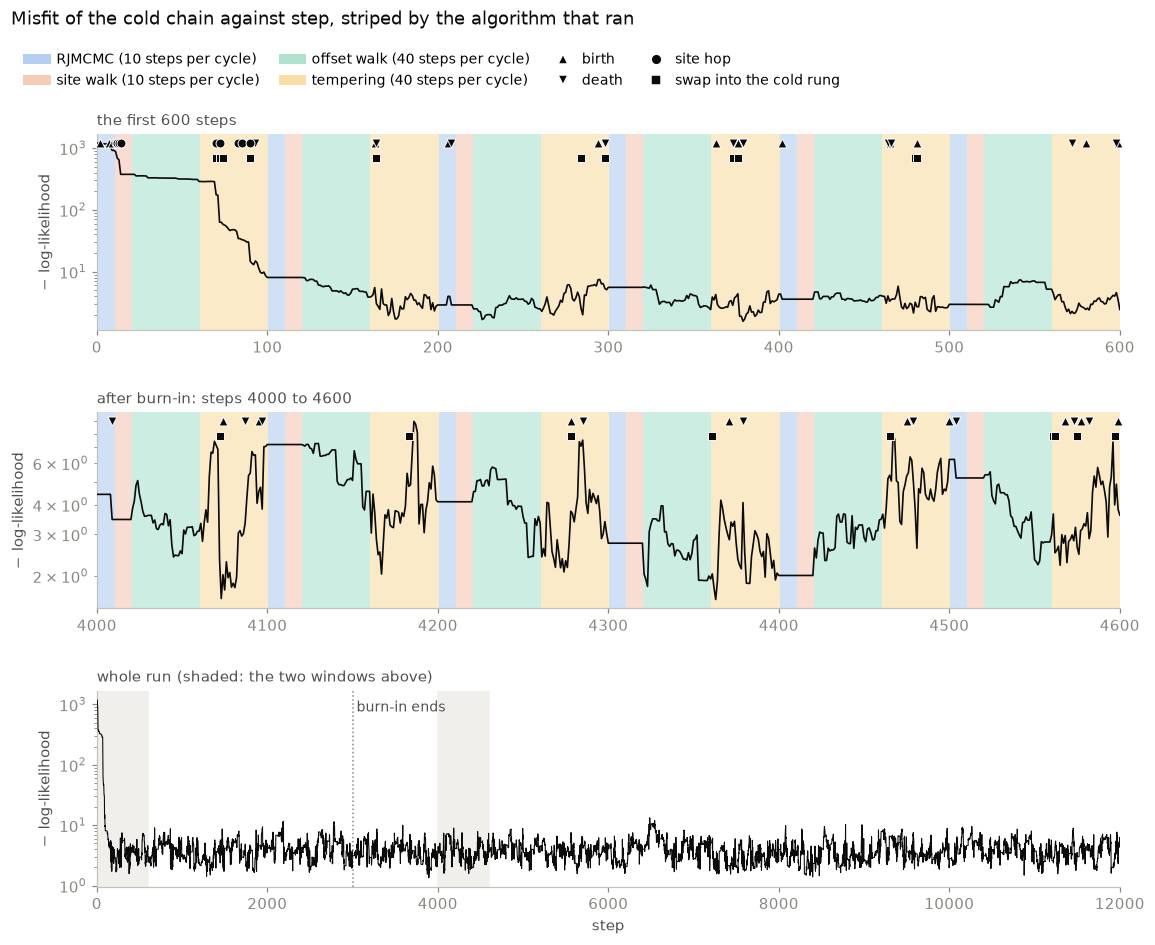

In [5]:
WINDOW = 600


def _stripes(ax, res, first, last):
    """Shade each contiguous run of one algorithm between two steps."""
    labels = res["algorithm"][first:last]            # steps first+1 .. last
    edges = np.flatnonzero(labels[1:] != labels[:-1]) + 1
    starts = np.concatenate([[0], edges])
    stops = np.concatenate([edges, [len(labels)]])
    for a, b in zip(starts, stops, strict=True):
        ax.axvspan(first + a + 0.5, first + b + 0.5,
                   color=ALGORITHM_COLOURS[labels[a]], alpha=0.22, lw=0,
                   zorder=0)


def _moves(ax, res, first, last):
    """Accepted configuration changes, along the top edge of the panel."""
    for key, marker, height in (("births", "^", 0.955), ("deaths", "v", 0.955),
                                ("hops", "o", 0.955), ("cold_swaps", "s", 0.88)):
        at = res[key][(res[key] > first) & (res[key] <= last)]
        ax.scatter(at, np.full(at.size, height), marker=marker, s=34,
                   color=C_INK, edgecolor="white", linewidths=0.6, zorder=4,
                   transform=ax.get_xaxis_transform(), clip_on=False)


def plot_algorithms(res):
    steps = np.arange(len(res["k"]))
    misfit = -res["log_like"]
    windows = [(0, WINDOW), (N_BURN + 1000, N_BURN + 1000 + WINDOW)]
    fig, axes = plt.subplots(3, 1, figsize=(12.0, 9.0),
                             gridspec_kw={"hspace": 0.42, "top": 0.87})
    for ax, (first, last), name in zip(
            axes[:2], windows, ("the first", "after burn-in:"), strict=True):
        _stripes(ax, res, first, last)
        _moves(ax, res, first, last)
        show = slice(first, last + 1)
        ax.plot(steps[show], misfit[show], color=C_INK, lw=1.1, zorder=3)
        ax.set_xlim(first, last)
        ax.set_yscale("log")
        ax.set_ylabel("− log-likelihood")
        ax.set_title(f"{name} {WINDOW} steps" if first == 0 else
                     f"{name} steps {first} to {last}",
                     loc="left", color="#52514e", fontsize=10)
    whole = axes[2]
    whole.plot(steps, misfit, color=C_INK, lw=0.7, zorder=3)
    for first, last in windows:
        whole.axvspan(first, last, color=C_SOFT, zorder=0)
    whole.axvline(N_BURN, color=C_MUTED, lw=1.0, ls=":", zorder=1)
    whole.text(N_BURN, 0.95, " burn-in ends", fontsize=9, color="#52514e",
               va="top", transform=whole.get_xaxis_transform())
    whole.set_xlim(0, len(steps) - 1)
    whole.set_yscale("log")
    whole.set_ylabel("− log-likelihood")
    whole.set_xlabel("step")
    whole.set_title("whole run (shaded: the two windows above)", loc="left",
                    color="#52514e", fontsize=10)

    handles = [Patch(facecolor=colour, alpha=0.35,
                     label=f"{name} ({BLOCKS[name]} steps per cycle)")
               for name, colour in ALGORITHM_COLOURS.items()]
    for marker, name in (("^", "birth"), ("v", "death"), ("o", "site hop"),
                         ("s", "swap into the cold rung")):
        handles.append(plt.Line2D([], [], marker=marker, ls="", color=C_INK,
                                  markeredgecolor="white", ms=7, label=name))
    fig.legend(handles=handles, loc="upper left", ncols=4, fontsize=9,
               bbox_to_anchor=(0.06, 0.965), handletextpad=0.4,
               columnspacing=1.4)
    fig.suptitle("Misfit of the cold chain against step, striped by the "
                 "algorithm that ran", x=0.06, y=0.995, ha="left", color=C_INK)
    plt.show()


plot_algorithms(main)

## 5. Inside the ladder

The misfit of every rung, sweep by sweep, for six tempering blocks after
burn-in. The cold rung is the darkest line. Each block starts with all
eight rungs on the cold rung's configuration, and the hot ones spread
upward from there within a few sweeps.

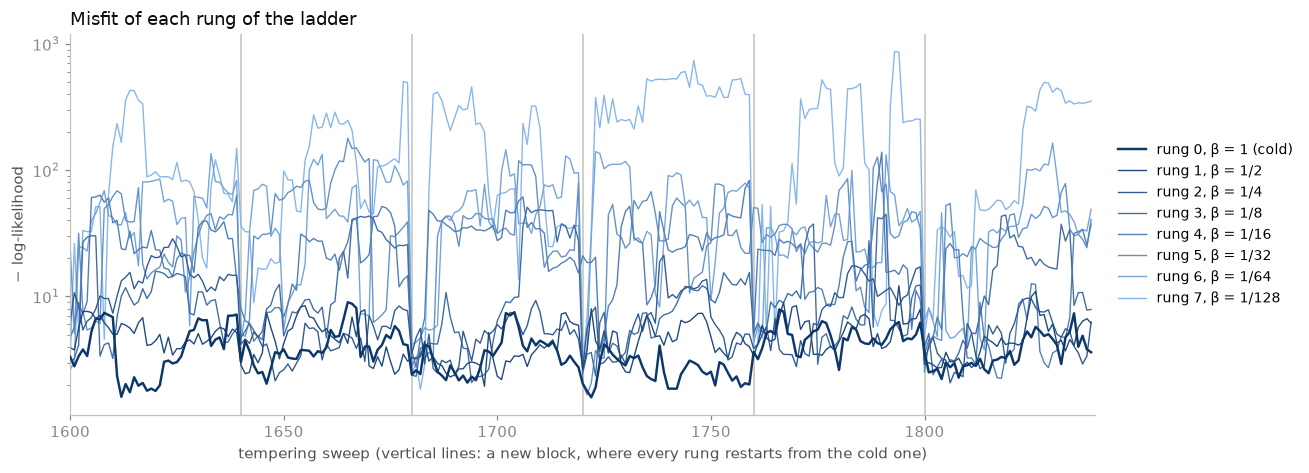

In [6]:
def plot_ladder(res, first_block=None, n_blocks=6):
    ladder = res["ladder"]
    per_block = BLOCKS["tempering"]
    if first_block is None:
        first_block = (N_BURN + 1000) // sum(BLOCKS.values())
    lo, hi = first_block * per_block, (first_block + n_blocks) * per_block
    misfit = -np.array(ladder.rung_log_like[lo:hi])       # (sweep, rung)
    sweeps = np.arange(lo, hi)
    ramp = LinearSegmentedColormap.from_list("rungs", ["#0d366b", "#86b6ef"])
    fig, ax = plt.subplots(figsize=(12.0, 4.4))
    for start in range(lo, hi, per_block):
        ax.axvline(start, color=C_AXIS, lw=1.0, zorder=1)
    for j in reversed(range(N_RUNGS)):
        ax.plot(sweeps, misfit[:, j], color=ramp(j / (N_RUNGS - 1)),
                lw=1.6 if j == 0 else 0.9, zorder=3 if j == 0 else 2)
    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_xlabel("tempering sweep (vertical lines: a new block, where every "
                  "rung restarts from the cold one)")
    ax.set_ylabel("− log-likelihood")
    handles = [plt.Line2D([], [], color=ramp(j / (N_RUNGS - 1)),
                          lw=1.6 if j == 0 else 0.9,
                          label="rung 0, β = 1 (cold)" if j == 0 else
                          f"rung {j}, β = 1/{round(1 / ladder.betas[j])}")
               for j in range(N_RUNGS)]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.01, 0.5),
              fontsize=9)
    ax.set_title("Misfit of each rung of the ladder", loc="left", color=C_INK)
    fig.tight_layout()
    plt.show()


plot_ladder(main)

## 6. Sites and spin count against step

Top: a row per site, filled where the site is occupied on the cold chain.
Bottom: the number of spins. The opening steps are shown beside the whole
run.

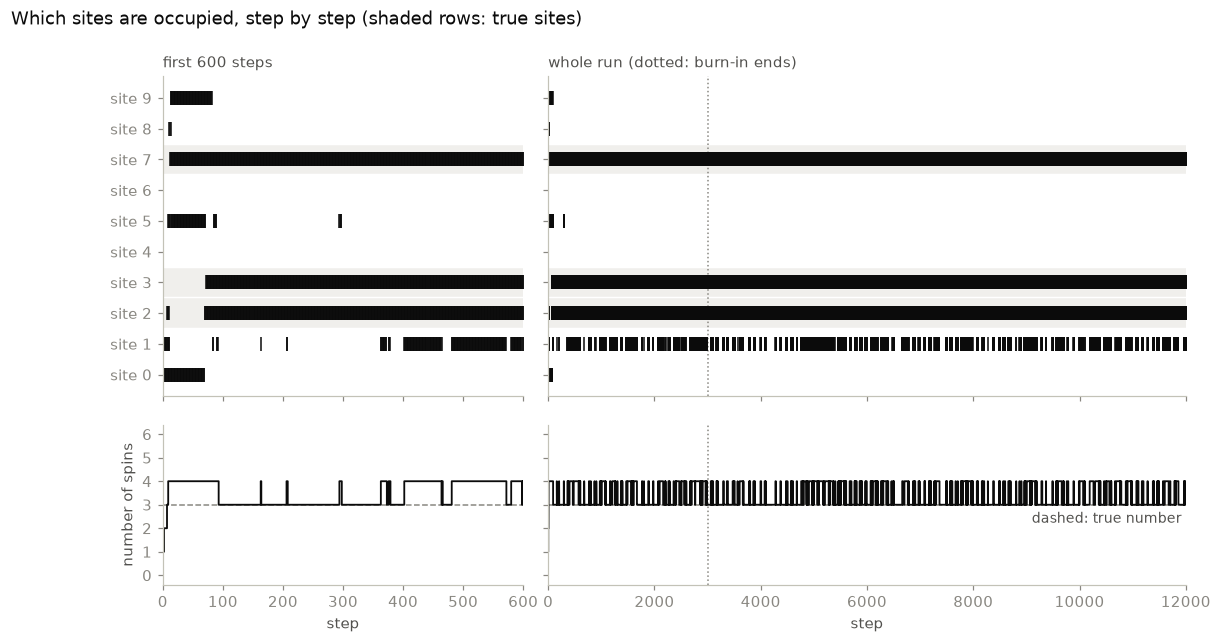

In [7]:
def plot_sites_and_count(res, opening=WINDOW):
    steps = np.arange(len(res["k"]))
    fig, axes = plt.subplots(
        2, 2, figsize=(12.0, 6.0), sharex="col", sharey="row",
        gridspec_kw={"width_ratios": [1.3, 2.3], "height_ratios": [2.0, 1],
                     "hspace": 0.12, "wspace": 0.05})
    for column, last in enumerate((opening, len(steps) - 1)):
        top, bottom = axes[0, column], axes[1, column]
        for s in TRUE_SITES:
            top.axhspan(s - 0.45, s + 0.45, color=C_SOFT, zorder=0)
        for i in range(N_SITES):
            on = np.flatnonzero(res["occupancy"][: last + 1, i])
            top.scatter(on, np.full(on.size, i), marker="|", s=90,
                        linewidths=1.0, color=C_INK, zorder=2)
        bottom.axhline(len(TRUE_SITES), color=C_MUTED, lw=1.0, ls="--",
                       zorder=1)
        bottom.plot(steps[: last + 1], res["k"][: last + 1],
                    drawstyle="steps-post", color=C_INK, lw=1.2, zorder=2)
        bottom.set_xlabel("step")
        if last > N_BURN:
            for ax in (top, bottom):
                ax.axvline(N_BURN, color=C_MUTED, lw=1.0, ls=":", zorder=1)
        for ax in (top, bottom):
            ax.set_xlim(0, last)
        top.set_title(f"first {opening} steps" if column == 0 else
                      "whole run (dotted: burn-in ends)",
                      loc="left", color="#52514e", fontsize=10)
    axes[0, 0].set_yticks(range(N_SITES), [f"site {i}" for i in range(N_SITES)])
    axes[0, 0].set_ylim(-0.7, N_SITES - 0.3)
    axes[1, 0].set_yticks(range(K_MAX + 1))
    axes[1, 0].set_ylim(-0.4, K_MAX + 0.4)
    axes[1, 0].set_ylabel("number of spins")
    axes[1, 1].text(len(steps) - 1, len(TRUE_SITES) - 0.3,
                    "dashed: true number ", ha="right", va="top", fontsize=9,
                    color="#52514e")
    fig.suptitle("Which sites are occupied, step by step "
                 "(shaded rows: true sites)", x=0.01, ha="left", color=C_INK)
    plt.show()


plot_sites_and_count(main)

## 7. What the posterior says

Left: how often each site is occupied after burn-in. Right: how often the
configuration has each number of spins.

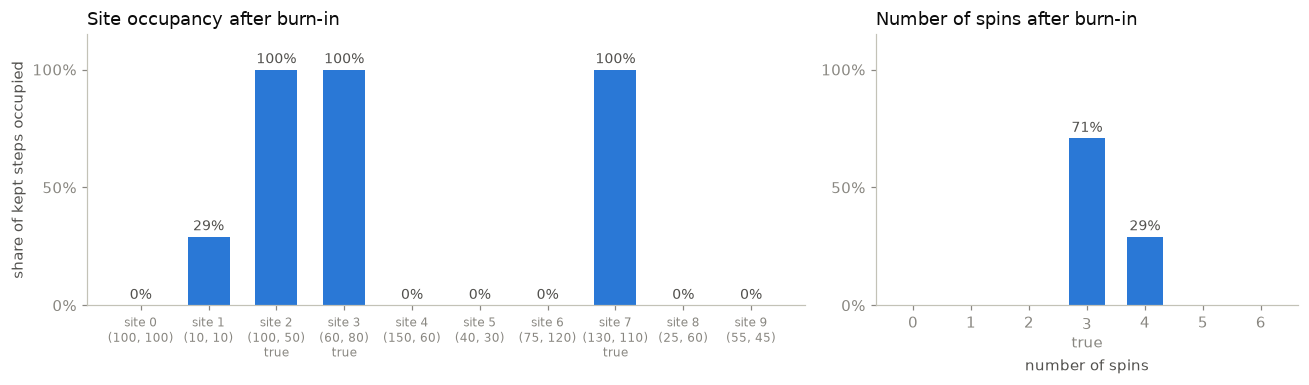

In [8]:
def plot_posterior(res):
    kept_occ = res["occupancy"][N_BURN:].mean(axis=0)
    k_share = np.bincount(res["k"][N_BURN:], minlength=K_MAX + 1) / len(
        res["k"][N_BURN:])
    fig, (left, right) = plt.subplots(
        1, 2, figsize=(12.0, 3.6), gridspec_kw={"width_ratios": [1.7, 1]})

    bars = left.bar(range(N_SITES), kept_occ, width=0.62, color=C_SAMPLE)
    left.bar_label(bars, labels=[f"{v:.0%}" for v in kept_occ], fontsize=9,
                   color="#52514e", padding=2)
    left.set_xticks(range(N_SITES), [
        f"site {i}\n({CENTRES[i, 0]:.0f}, {CENTRES[i, 1]:.0f})"
        + ("\ntrue" if i in TRUE else "") for i in range(N_SITES)], fontsize=8)
    left.set_ylim(0, 1.15)
    left.set_yticks([0, 0.5, 1.0], ["0%", "50%", "100%"])
    left.set_ylabel("share of kept steps occupied")
    left.set_title("Site occupancy after burn-in", loc="left", color=C_INK)

    bars = right.bar(range(K_MAX + 1), k_share, width=0.62, color=C_SAMPLE)
    right.bar_label(bars, labels=[f"{v:.0%}" if v > 0 else "" for v in k_share],
                    fontsize=9, color="#52514e", padding=2)
    right.set_xticks(range(K_MAX + 1), [
        f"{n}\ntrue" if n == len(TRUE_SITES) else str(n)
        for n in range(K_MAX + 1)])
    right.set_ylim(0, 1.15)
    right.set_yticks([0, 0.5, 1.0], ["0%", "50%", "100%"])
    right.set_xlabel("number of spins")
    right.set_title("Number of spins after burn-in", loc="left", color=C_INK)
    fig.tight_layout()
    plt.show()


plot_posterior(main)

This is seed 0, the seed that went wrong in the previous notebook. There,
a spin born on site 9 in the opening steps stayed for the whole run. Here
the same spin is born at the same point and is gone by step 85, inside the
first tempering block, and site 9 is not occupied at any kept step.

What is left is the answer the other seed gave before: the three true
sites always occupied, and a fourth spin on site 1 for a little under a
third of the time. Site 1, at (10, 10) kHz, barely changes the signal, and
no amount of sampling will decide whether a spin is there.

## 8. The walk in coupling space, and within each site

Every site's rectangle to scale, then one panel per site with the offset as
a percentage of the table value, so that every rectangle is the same ±10%
square. Grey points are from burn-in.

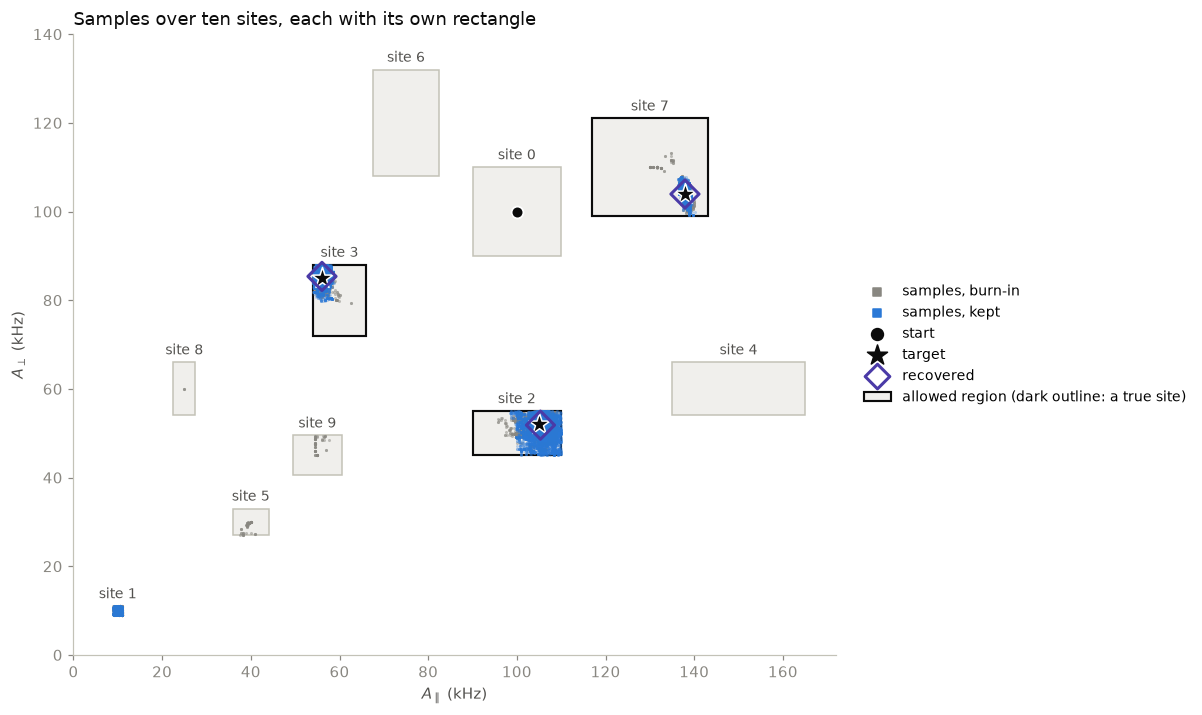

In [9]:
def _site_markers(ax, res, i, relative=False):
    """Start, target and recovered markers for site ``i``, if it has them."""
    def place(point):
        if not relative:
            return point
        return 100.0 * (np.asarray(point) - CENTRES[i]) / CENTRES[i]

    best = res["best"]
    if i in START_SITES:
        ax.scatter(*place(CENTRES[i]), s=60, marker="o", color=C_INK,
                   edgecolor="white", linewidths=1.2, zorder=6)
    if i in TRUE:
        ax.scatter(*place(CENTRES[i] + np.array(TRUE[i])), s=210, marker="*",
                   color=C_INK, edgecolor="white", linewidths=1.0, zorder=7)
    for slot in np.flatnonzero(res["site"][best] == i):
        ax.scatter(*place((res["a_par"][best, slot], res["a_perp"][best, slot])),
                   s=170, marker="D", facecolor="none", edgecolor=C_RECOVERED,
                   linewidths=2.0, zorder=8)


def plot_coupling_space(res):
    kept = np.arange(len(res["k"])) >= N_BURN
    fig, ax = plt.subplots(figsize=(11.0, 6.6))
    for i in range(N_SITES):
        is_true = i in TRUE
        ax.add_patch(Rectangle(
            CENTRES[i] - HALF[i], 2 * HALF[i, 0], 2 * HALF[i, 1],
            facecolor=C_SOFT, edgecolor=C_INK if is_true else C_AXIS,
            lw=1.4 if is_true else 1.0, zorder=0))
        ax.annotate(f"site {i}", (CENTRES[i, 0], CENTRES[i, 1] + HALF[i, 1]),
                    xytext=(0, 3), textcoords="offset points", ha="center",
                    va="bottom", fontsize=9, color="#52514e")
        _site_markers(ax, res, i)
    ax.scatter(res["a_par"][~kept], res["a_perp"][~kept], s=4, color=C_MUTED,
               alpha=0.5, linewidths=0, zorder=2)
    ax.scatter(res["a_par"][kept], res["a_perp"][kept], s=4, color=C_SAMPLE,
               alpha=0.3, linewidths=0, zorder=3)

    ax.scatter([], [], s=30, marker="s", color=C_MUTED, label="samples, burn-in")
    ax.scatter([], [], s=30, marker="s", color=C_SAMPLE, label="samples, kept")
    ax.scatter([], [], s=60, marker="o", color=C_INK, label="start")
    ax.scatter([], [], s=190, marker="*", color=C_INK, label="target")
    ax.scatter([], [], s=130, marker="D", facecolor="none",
               edgecolor=C_RECOVERED, linewidths=2.0, label="recovered")
    ax.add_patch(Rectangle((0, 0), 0, 0, facecolor=C_SOFT, edgecolor=C_INK,
                           lw=1.4,
                           label="allowed region (dark outline: a true site)"))
    ax.set_aspect("equal")
    ax.set_xlim(0, 172)
    ax.set_ylim(0, 140)
    ax.set_xlabel(r"$A_\parallel$ (kHz)")
    ax.set_ylabel(r"$A_\perp$ (kHz)")
    ax.set_title("Samples over ten sites, each with its own rectangle",
                 loc="left", color=C_INK)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_within_sites(res):
    kept = np.arange(len(res["k"])) >= N_BURN
    kept_occ = res["occupancy"][N_BURN:].mean(axis=0)
    fig, axes = plt.subplots(2, 5, figsize=(13.5, 6.0), sharex=True,
                             sharey=True, layout="constrained")
    for i, ax in enumerate(axes.flat):
        ax.add_patch(Rectangle((-10, -10), 20, 20, facecolor=C_SOFT,
                               edgecolor=C_INK if i in TRUE else C_AXIS,
                               lw=1.4 if i in TRUE else 1.0, zorder=0))
        ax.axhline(0.0, color=C_AXIS, lw=0.8, zorder=1)
        ax.axvline(0.0, color=C_AXIS, lw=0.8, zorder=1)
        here = res["site"] == i
        x = 100.0 * res["d_par"] / CENTRES[i, 0]
        y = 100.0 * res["d_perp"] / CENTRES[i, 1]
        early, late = here & ~kept[:, None], here & kept[:, None]
        ax.scatter(x[early], y[early], s=5, color=C_MUTED, alpha=0.5,
                   linewidths=0, zorder=2)
        ax.scatter(x[late], y[late], s=5, color=C_SAMPLE, alpha=0.3,
                   linewidths=0, zorder=3)
        _site_markers(ax, res, i, relative=True)
        ax.set_xlim(-11.5, 11.5)
        ax.set_ylim(-11.5, 11.5)
        ax.set_aspect("equal")
        ax.set_title(f"site {i} ({CENTRES[i, 0]:.0f}, {CENTRES[i, 1]:.0f})\n"
                     f"±{HALF[i, 0]:.1f} × ±{HALF[i, 1]:.1f} kHz, "
                     f"occupied {kept_occ[i]:.0%}",
                     loc="left", color=C_INK, fontsize=9)
    for ax in axes[1]:
        ax.set_xlabel(r"$\delta_\parallel$ (% of $A_\parallel$)")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$\delta_\perp$ (% of $A_\perp$)")
    fig.suptitle("Within sites: each site's offset, as a percentage of its "
                 "table value (dark outline: a true site)", x=0.01, ha="left",
                 color=C_INK)
    plt.show()


plot_coupling_space(main)

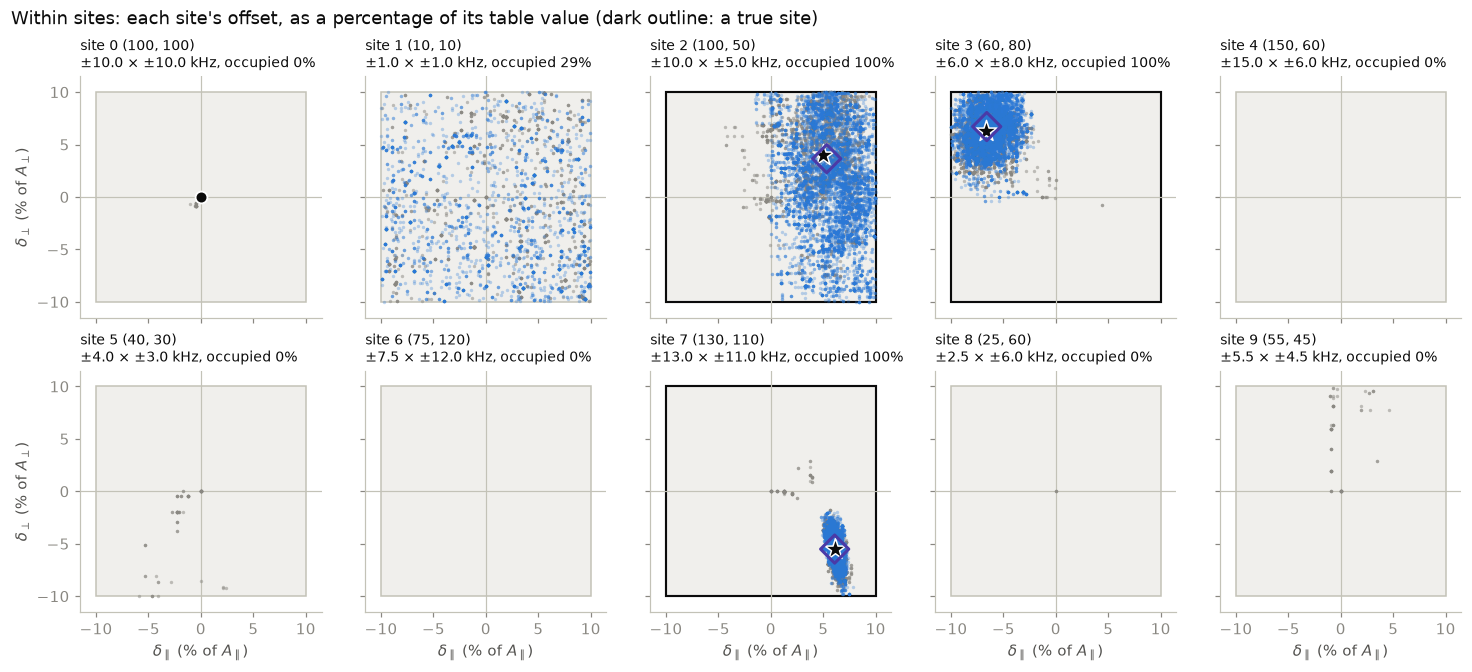

In [10]:
plot_within_sites(main)

## 9. The signals

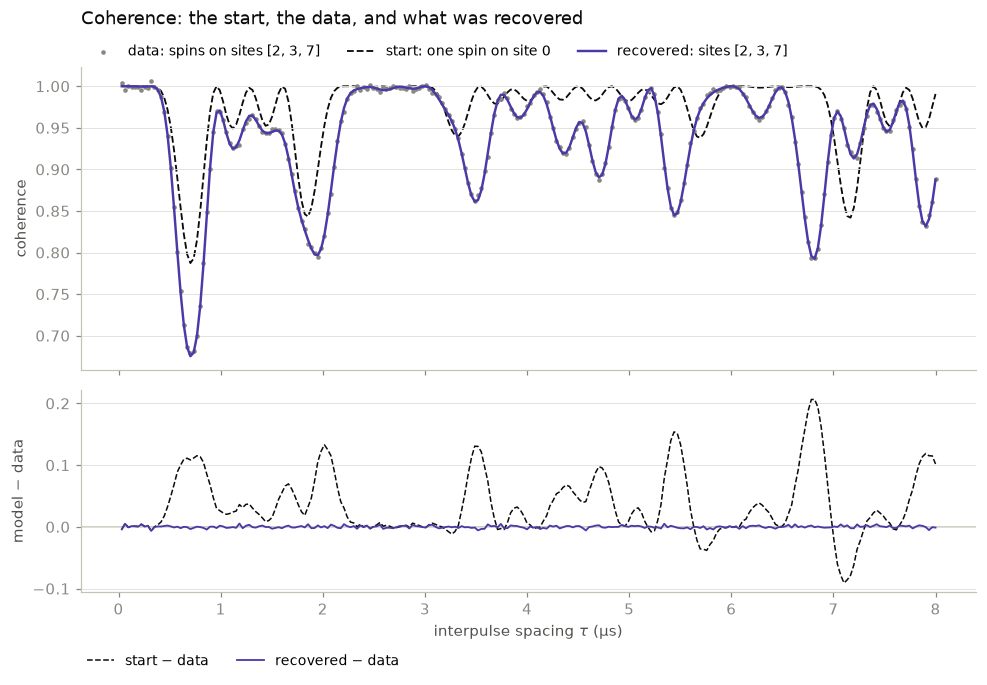

rms residual, recovered: 0.0021   (data noise 0.002)


In [11]:
def plot_signals(res):
    sig_initial = simulate_coherence(res["initial"], blank, table, model)
    sig_recovered = simulate_coherence(res["recovered"], blank, table, model)
    measured = data.data_all
    tau_us = tau * 1e3
    _, (top, bottom) = plt.subplots(
        2, 1, figsize=(10.5, 6.2), sharex=True,
        gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08})
    top.scatter(tau_us, measured, s=9, color=C_MUTED, linewidths=0, zorder=2,
                label=f"data: spins on sites {list(TRUE_SITES)}")
    top.plot(tau_us, sig_initial, color=C_INK, lw=1.2, ls="--", zorder=1,
             label=f"start: one spin on site {START_SITES[0]}")
    top.plot(tau_us, sig_recovered, color=C_RECOVERED, lw=1.6, zorder=3,
             label=f"recovered: sites {[int(s) for s in res['modal']]}")
    top.set_ylabel("coherence")
    top.set_title("Coherence: the start, the data, and what was recovered",
                  loc="left", color=C_INK, pad=28)
    top.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=3,
               fontsize=9, borderaxespad=0.2)
    top.grid(axis="y")

    bottom.axhline(0.0, color=C_AXIS, lw=1.0, zorder=1)
    bottom.plot(tau_us, sig_initial - measured, color=C_INK, lw=1.0, ls="--",
                zorder=2, label="start − data")
    bottom.plot(tau_us, sig_recovered - measured, color=C_RECOVERED, lw=1.2,
                zorder=3, label="recovered − data")
    bottom.set_xlabel(r"interpulse spacing $\tau$ (µs)")
    bottom.set_ylabel("model − data")
    bottom.legend(loc="upper left", bbox_to_anchor=(0.0, -0.28), ncols=2,
                  fontsize=9, borderaxespad=0.0)
    bottom.grid(axis="y")
    plt.show()
    rms = np.sqrt(np.mean((sig_recovered - measured) ** 2))
    print(f"rms residual, recovered: {rms:.4f}   (data noise {DATA_NOISE})")


plot_signals(main)

## 10. With and without tempering

The test tempering has to pass is the one the previous notebook failed:
runs that differ only in their random seed should agree. Seeds 0 and 1 are
run with the tempering block and without it, on the same data. Without it,
the schedule is the previous notebook's three blocks.

In [12]:
runs = {(0, True): main}
for seed, tempering in ((1, True), (0, False), (1, False)):
    runs[(seed, tempering)] = run_walk(seed, tempering=tempering)

kept_steps = N_STEPS + 1 - N_BURN
print(f"{'':24s}{'true set':>10s}{'true set + site 1':>19s}"
      f"{'any set with site 9':>21s}")
for tempering in (False, True):
    for seed in (0, 1):
        res = runs[(seed, tempering)]
        counts = res["config_counts"]
        true_set = counts.get(TRUE_SITES, 0) / kept_steps
        plus_one = counts.get(tuple(sorted((*TRUE_SITES, 1))), 0) / kept_steps
        with_nine = res["occupancy"][N_BURN:, 9].mean()
        name = f"{'with' if tempering else 'without'} tempering, seed {seed}"
        print(f"{name:24s}{true_set:10.0%}{plus_one:19.0%}{with_nine:21.0%}")

                          true set  true set + site 1  any set with site 9
without tempering, seed 0        0%                 0%                 100%
without tempering, seed 1       65%                35%                   0%
with tempering, seed 0         71%                29%                   0%
with tempering, seed 1         59%                36%                   6%


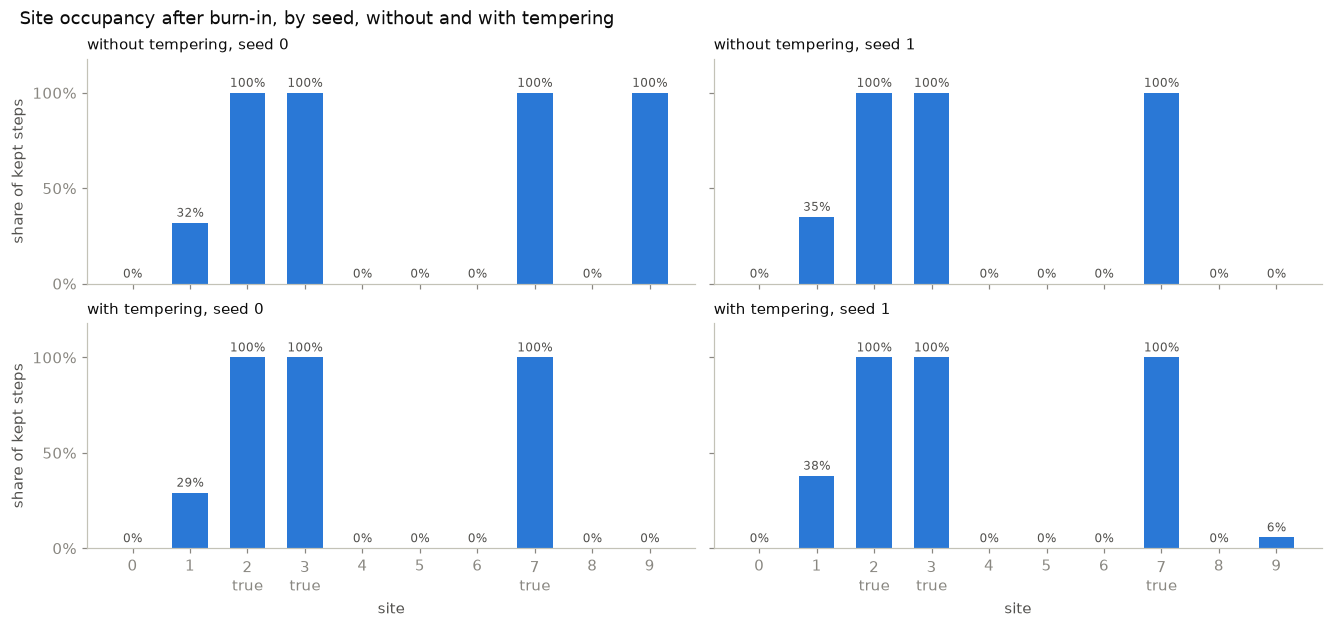

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12.0, 5.6), sharex=True, sharey=True,
                         layout="constrained")
for row, tempering in enumerate((False, True)):
    for column, seed in enumerate((0, 1)):
        ax = axes[row, column]
        share = runs[(seed, tempering)]["occupancy"][N_BURN:].mean(axis=0)
        bars = ax.bar(range(N_SITES), share, width=0.62, color=C_SAMPLE)
        ax.bar_label(bars, labels=[f"{v:.0%}" for v in share], fontsize=8,
                     color="#52514e", padding=2)
        ax.set_ylim(0, 1.18)
        ax.set_yticks([0, 0.5, 1.0], ["0%", "50%", "100%"])
        ax.set_title(f"{'with' if tempering else 'without'} tempering, "
                     f"seed {seed}", loc="left", color=C_INK, fontsize=10)
for ax in axes[1]:
    ax.set_xticks(range(N_SITES), [
        f"{i}\ntrue" if i in TRUE else str(i) for i in range(N_SITES)])
    ax.set_xlabel("site")
for ax in axes[:, 0]:
    ax.set_ylabel("share of kept steps")
fig.suptitle("Site occupancy after burn-in, by seed, without and with "
             "tempering", x=0.01, ha="left", color=C_INK)
plt.show()

Without tempering the two seeds contradict each other: one never has a
spin on site 9, the other always does. With tempering they agree on the
three true sites, put site 1 at 29% and 38%, and put site 9 at 0% and 6%.

Three things to take from this.

- **The extra spin on site 9 was a trap, not half of the answer.** Its best
  fit is almost as good as the true set's, which made it look like an equal
  alternative. Once the chain can move between the two, it spends a few
  percent of its time there at most. A good fit at one point is not the
  same as a large share of the posterior.
- **The agreement is approximate.** Site 1 differs by nine points between
  the seeds and site 9 by six. Two seeds that roughly agree are evidence
  that the chain is mixing, not a measurement of how well. That needs more
  chains and a statistic computed across them.
- **Tempering is expensive.** A sweep moves all eight rungs, 48 moves for
  one recorded step, so the 4,800 sweeps of this run are about 230,000
  moves against 7,200 for the three single-chain blocks. A smaller ladder
  was not enough: with six rungs and 20 sweeps a cycle, one seed in four
  still held site 9 for the whole run.